In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard library
import gc
import logging
from pathlib import Path

import shap
import xgboost as xgb
from dask.distributed import Client, LocalCluster
from Experiment import Experiment
from newutils.data.Dataset import Dataset
from newutils.other.helpers import init_context
from oldutils.types import TimeRange

init_context()

/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

In [4]:
HORIZON_HISTORY = TimeRange.YEAR
HORIZON_FORECAST = TimeRange.WEEK
PARTITION_SIZE = "50MB"
N_WORKERS = 2

COL_GAUGE_ID = "gauge_id"
TARGETS = ["q_mm_day"]

In [ ]:
cluster = LocalCluster(
    dashboard_address=":8789",
    asynchronous=False,
    n_workers=N_WORKERS,
    threads_per_worker=1,
    memory_limit="2.5GB",
)
client = Client(cluster)

In [ ]:
outpath = Path("artifacts")
outpath.mkdir(parents=True, exist_ok=True)
dataset = Dataset(client)
dataset.create(num_load=12)

2025-05-13 09:43:39,901 - newutils.data.Dataset - INFO - Create dataframe.


2025-05-13 09:43:39,902 - newutils.data.Dataset - INFO - Load time series.
2025-05-13 09:43:39,917 - newutils.data.Dataset - WARNING - DEBUG: frac=0.1
2025-05-13 09:43:39,918 - newutils.data.Dataset - INFO - Persist.
2025-05-13 09:43:40,845 - newutils.data.Dataset - INFO - Persist.
2025-05-13 09:43:40,921 - newutils.data.Dataset - INFO - Make repartition (10MB).
2025-05-13 09:43:40,923 - newutils.data.Dataset - INFO - Generate lags features.
2025-05-13 09:43:42,137 - newutils.data.Dataset - INFO - Make repartition (50MB).
2025-05-13 09:43:42,138 - newutils.data.Dataset - INFO - Persist.
2025-05-13 09:43:50,440 - distributed.worker.memory - WARNING - Worker is at 90% memory usage. Pausing worker.  Process memory: 2.11 GiB -- Worker memory limit: 2.33 GiB
2025-05-13 09:43:50,440 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#mem

KilledWorker: Attempted to run task ('_add_lags-ac3f459c77b19fa44f6e7cb1b6765f6a', 0) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:33005. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

In [ ]:
experiment = Experiment(client, outpath, dataset)

In [ ]:
params = {
    "tree_method": "hist",
    "learning_rate": 0.001,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 1,
    "eval_metric": "mape",
    "num_boost_round": 100,
    "verbose_eval": 10,
    "n_jobs": -1,
    "num_load": 12,
}

experiment.make(params, num_load=4)

2025-05-13 09:40:13,928 - Experiment - INFO - Prepare experiment.
2025-05-13 09:40:13,929 - newutils.data.Dataset - INFO - Make train test split to X and y.


2025-05-13 09:40:29,813 - Experiment - WARNING - DEBUG: Use only one feature to predict.
2025-05-13 09:40:29,814 - newutils.data.Dataset - INFO - Create XGBoost DaskDMatrix.
2025-05-13 09:40:32,977 - Experiment - INFO - Start model training.
[09:40:33] Task [xgboost.dask-0]:tcp://127.0.0.1:42233 got rank 0[09:40:33] Task [xgboost.dask-1]:tcp://127.0.0.1:35981 got rank 1

[09:40:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "num_boost_round", "num_load", "verbose_eval" } are not used.
[09:40:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "num_boost_round", "num_load", "verbose_eval" } are not used.


[09:40:36] [0]	train-mape:6.63491
[09:40:41] [10]	train-mape:5.02797
[09:40:46] [20]	train-mape:3.80791
[09:40:51] [30]	train-mape:3.59122
[09:40:56] [40]	train-mape:3.44747
[09:41:00] [50]	train-mape:3.28911
[09:41:05] [60]	train-mape:3.19646
[09:41:10] [70]	train-mape:3.05243
[09:41:15] [80]	train-mape:2.90256
[09:41:20] [90]	train-mape:2.76297
[09:41:25] [99]	tra

In [ ]:
# client.close()
# cluster.close()
# gc.collect()

In [ ]:
dataset = Dataset(client)
dataset.create(num_load=1)

2025-05-13 09:41:25,631 - newutils.data.Dataset - INFO - Create dataframe.
2025-05-13 09:41:25,633 - newutils.data.Dataset - INFO - Load time series.


2025-05-13 09:41:25,643 - newutils.data.Dataset - WARNING - DEBUG: frac=0.1
2025-05-13 09:41:25,646 - newutils.data.Dataset - INFO - Persist.
2025-05-13 09:41:25,680 - newutils.data.Dataset - INFO - Persist.
2025-05-13 09:41:25,725 - newutils.data.Dataset - INFO - Make repartition (10MB).
2025-05-13 09:41:25,727 - newutils.data.Dataset - INFO - Generate lags features.
2025-05-13 09:41:27,375 - newutils.data.Dataset - INFO - Make repartition (50MB).
2025-05-13 09:41:27,376 - newutils.data.Dataset - INFO - Persist.
2025-05-13 09:41:32,503 - newutils.data.Dataset - INFO - Clear dataset from nans.
2025-05-13 09:41:32,505 - newutils.data.Dataset - INFO - Add static features.
2025-05-13 09:41:32,506 - newutils.data.Dataset - INFO - Load static features.
2025-05-13 09:41:32,676 - newutils.data.Dataset - INFO - Persist.
2025-05-13 09:41:36,077 - newutils.data.Dataset - INFO - Make repartition (10MB).
2025-05-13 09:41:36,078 - newutils.data.Dataset - INFO - Persist.


In [ ]:
X_test, y_test, _, _ = dataset.train_test_Xy_split()
y_test = y_test[Dataset.TARGET]

2025-05-13 09:41:42,305 - newutils.data.Dataset - INFO - Make train test split to X and y.


In [ ]:
booster = xgb.Booster()
booster.load_model(experiment.model_paths[-1])

In [ ]:
explainer = shap.Explainer(booster, experiment.X_train.compute())
shap_values = explainer.shap_values(X_test.compute(), y_test.compute())

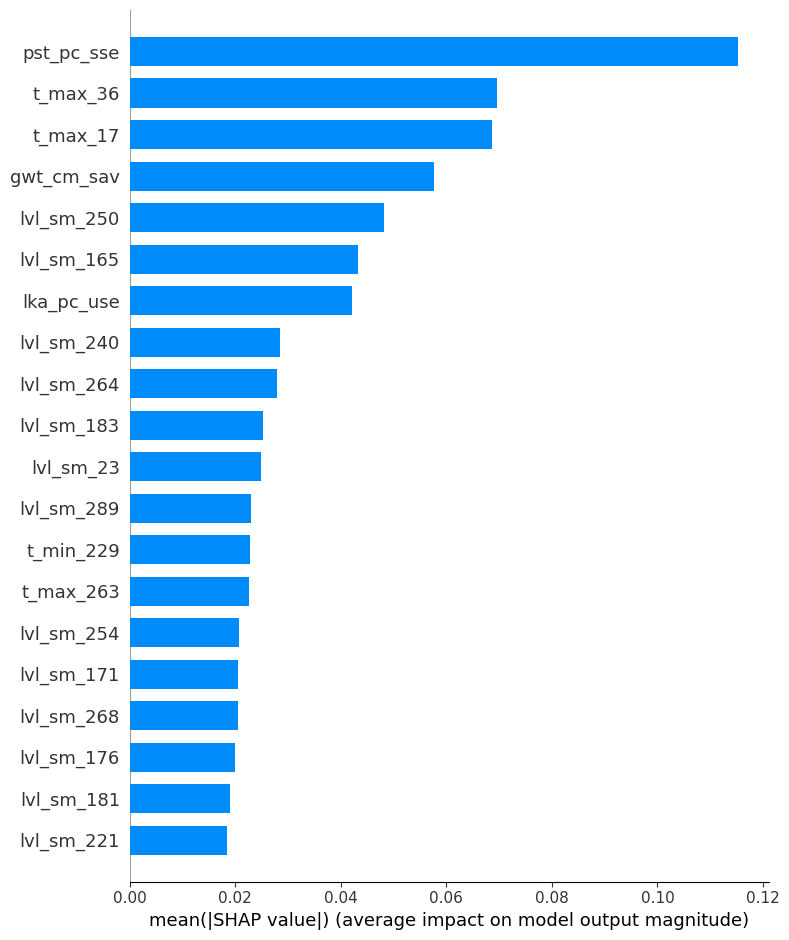

In [ ]:
shap.summary_plot(shap_values, X_test.compute(), plot_type="bar")

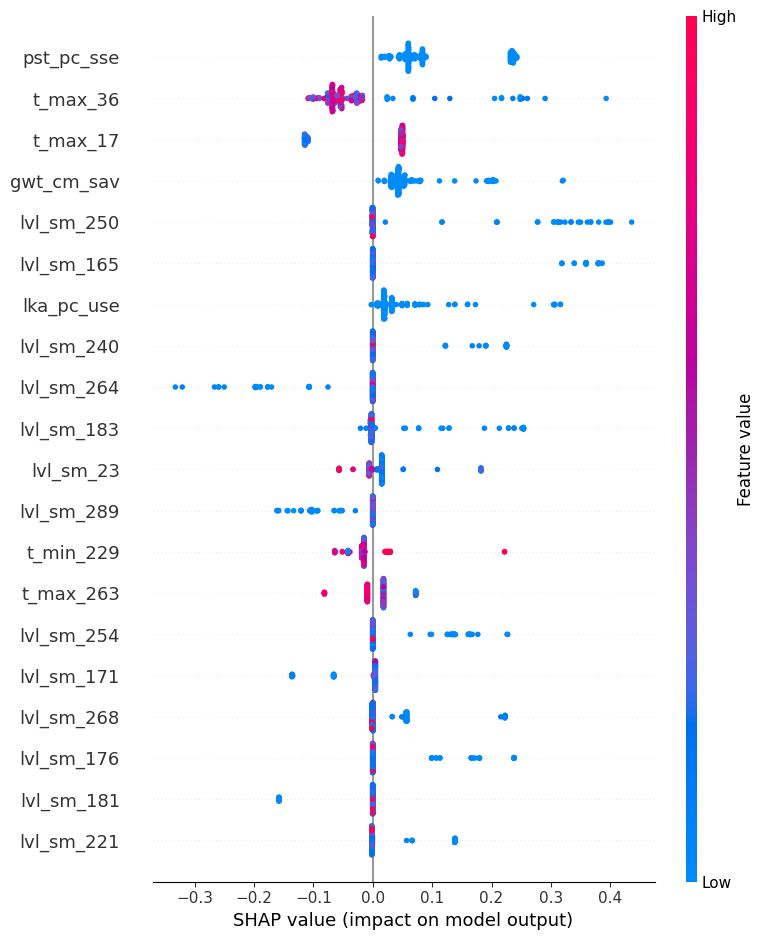

In [ ]:
shap.summary_plot(shap_values, X_test.compute())